In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/placementByGeolocation/placementByGeolocationApp/refs/heads/checkpoint3/df_cafes_.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9218 entries, 0 to 9217
Data columns (total 77 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   name                                  9218 non-null   object 
 1   type                                  9218 non-null   object 
 2   cuisine                               5636 non-null   object 
 3   website                               9218 non-null   int64  
 4   lat                                   9218 non-null   float64
 5   lon                                   9218 non-null   float64
 6   dgis_general_rating                   9218 non-null   float64
 7   dgis_general_review_count_with_stars  9218 non-null   float64
 8   dgis_org_rating                       9218 non-null   float64
 9   dgis_org_review_count                 9218 non-null   float64
 10  city                                  9218 non-null   object 
 11  brand            

In [3]:
df = df.drop("brand", axis=1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9218 entries, 0 to 9217
Data columns (total 76 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   name                                  9218 non-null   object 
 1   type                                  9218 non-null   object 
 2   cuisine                               5636 non-null   object 
 3   website                               9218 non-null   int64  
 4   lat                                   9218 non-null   float64
 5   lon                                   9218 non-null   float64
 6   dgis_general_rating                   9218 non-null   float64
 7   dgis_general_review_count_with_stars  9218 non-null   float64
 8   dgis_org_rating                       9218 non-null   float64
 9   dgis_org_review_count                 9218 non-null   float64
 10  city                                  9218 non-null   object 
 11  direct_competitor

In [5]:
target = "dgis_general_rating"
drop_cols = ['name', 'website', 'dgis_org_rating',
             'nearest_museum_name', 'nearest_theatre_name',
             'nearest_gallery_name', 'nearest_park_name',
             target, 'dgis_general_review_count_with_stars']
X = df.drop(columns=drop_cols, errors='ignore')
y = df[target]
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
categorical_features

['type', 'cuisine', 'city']

In [6]:
for col in categorical_features:
    X[col] = X[col].astype('category')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_features, reference=train_data)

In [7]:
params = {
    'objective': 'regression',        # для регрессии
    'metric': 'rmse',                 # метрика
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

model = lgb.train(
    params,
    train_data,
    valid_sets=[test_data],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2: {r2:.4f}")


Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.674119
[200]	valid_0's rmse: 0.670008
Early stopping, best iteration is:
[219]	valid_0's rmse: 0.669804
RMSE: 0.6698
MAE: 0.4947
R2: 0.2015


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

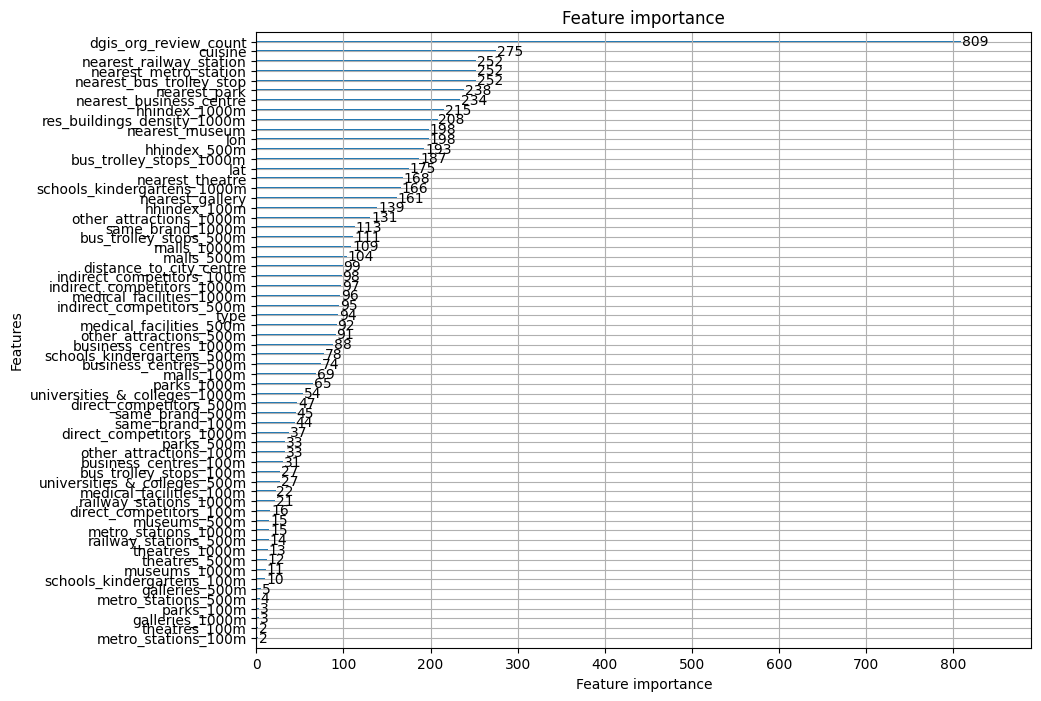

In [8]:
lgb.plot_importance(model, figsize=(10, 8))

In [9]:
pip install optuna

In [10]:
import optuna

In [11]:
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def objective(trial):
    # Параметры, которые будем оптимизировать
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'boosting_type': 'gbdt',
        'verbosity': -1,
        'random_state': 42,
        'num_leaves': trial.suggest_int('num_leaves', 10, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0, 1),
    }

    # Для каждого trial делаем своё разбиение train/validation из X_temp, y_temp
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=trial.number)

    train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=categorical_features)
    val_data = lgb.Dataset(X_val, label=y_val, categorical_feature=categorical_features, reference=train_data)

    model = lgb.train(
        params,
        train_data,
        valid_sets=[val_data],
        num_boost_round=1000,
        callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)]
    )

    y_pred = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    return rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

[I 2026-03-26 18:25:06,487] A new study created in memory with name: no-name-c017f511-e1f1-42dc-8cde-e13a3e30962d


  0%|          | 0/50 [00:00<?, ?it/s]

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[134]	valid_0's rmse: 0.704596
[I 2026-03-26 18:25:11,919] Trial 0 finished with value: 0.7045956893044482 and parameters: {'num_leaves': 134, 'learning_rate': 0.043915842884818014, 'feature_fraction': 0.5490970117114968, 'bagging_fraction': 0.9873728093796548, 'bagging_freq': 8, 'min_child_samples': 51, 'lambda_l1': 0.033780877924247665, 'lambda_l2': 4.927393019905809e-07, 'min_split_gain': 0.6732552533953611}. Best is trial 0 with value: 0.7045956893044482.
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[122]	valid_0's rmse: 0.697471
[I 2026-03-26 18:25:24,052] Trial 1 finished with value: 0.6974708933608413 and parameters: {'num_leaves': 292, 'learning_rate': 0.03274759749868713, 'feature_fraction': 0.6767908049725344, 'bagging_fraction': 0.9180177303847197, 'bagging_freq': 6, 'min_child_samples': 48, 'lambda_l1': 0.06916332080326747, 'lamb

In [12]:
print("Best trial:")
best_trial = study.best_trial
print(f"  RMSE: {best_trial.value:.4f}")
print("  Params:")
for key, value in best_trial.params.items():
    print(f"    {key}: {value}")


best_params = best_trial.params
best_params.update({
    'objective': 'regression',
    'metric': 'rmse',
    'verbosity': -1,
    'random_state': 42,
})

train_data_full = lgb.Dataset(X_temp, label=y_temp, categorical_feature=categorical_features)
test_data = lgb.Dataset(X_test, label=y_test, categorical_feature=categorical_features, reference=train_data_full)

model_final = lgb.train(
    best_params,
    train_data_full,
    valid_sets=[test_data],
    num_boost_round=1000,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

y_pred_test = model_final.predict(X_test)

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"\nFinal results on test set:")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE: {mae_test:.4f}")
print(f"R2: {r2_test:.4f}")

Best trial:
  RMSE: 0.6629
  Params:
    num_leaves: 101
    learning_rate: 0.017734603423750064
    feature_fraction: 0.7661133751966562
    bagging_fraction: 0.8379346316216488
    bagging_freq: 3
    min_child_samples: 29
    lambda_l1: 0.8848843180073847
    lambda_l2: 0.024331647181601385
    min_split_gain: 0.05308761654630302
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.676343
[200]	valid_0's rmse: 0.668555
Early stopping, best iteration is:
[233]	valid_0's rmse: 0.667746

Final results on test set:
RMSE: 0.6677
MAE: 0.4945
R2: 0.2064
